In [1]:
from typing import TypedDict,List
from langgraph.graph import StateGraph, START,END
import random

In [ ]:
class GameState(TypedDict):
    player_name:str
    target_number:int
    guesses:List[int]
    hint:str
    attempts:int
    lower_bound:int
    higher_bound:int

def setup(state:GameState)->GameState:
    """This is the initial state where user get information"""
    state['player_name']=f"Welcome to the game {state['player_name']}"
    state['target_number']=random.randint(1,20)
    state['guesses']=[]
    state['hint']=f"Guess Started, try to guess the number"
    state['attempts']=0
    state['lower_bound']=1
    state['higher_bound']=20
    print(f"{state['player_name']} the game has begun try to guess an number between 1 and 20")
    return state

def guesser(state:GameState)->GameState:
    """This function is used to Guess the number"""
    possible_guesses=[i for i in range(state['lower_bound'],state['higher_bound']) if i not in state['guesses']]
    if possible_guesses:
        guess=random.choice(possible_guesses)
    else:
        guess=random.randint(state['lower_bound'],state['higher_bound'])
    
    state['guesses'].append(guess)
    state['attempts']+=1
    print(f"Attempt {state['attempts']}:Guessing {guess} in Current Range({state['lower_bound']}-{state['higher_bound']})")
    return state

def hint_node(state:GameState)->GameState:
    """here we provide a hint based on the last guess and update the bounds"""
    latest_guess=state['guesses'][-1]
    target=state['target_number']

    if latest_guess<target:
        state['hint']= f"The Guess {latest_guess} Too lower, Try Higher"

        state['lower_bound']=max(state['lower_bound'],latest_guess+1)
        print(f"Hint: {state['hint']}")
    elif latest_guess>target:
        state['hint']= f"The Guess {latest_guess} Too higher, Try lower"

        state['higher_bound']=min(state['higher_bound'],latest_guess-1)
        print(f"Hint: {state['hint']}")
    else:
        print(f"You have Found the correct number in {state['attempts']} attempts")
    
    return state

def should_continue(state:GameState)->GameState:
    """ These will decide the flow whether the loop should continue or not"""
    latest_guess=state['guesses'][-1]
    if latest_guess==state['target_number']:
        print(f"Game Over, You found the number {state['target_number']}.")
        return 'end'
    elif state['attempts']>7:
        print(f"You have reached the maximum attempts")
        return 'end'
    else:
        print(f"Continuing:{state['attempts']}/7 attempts used.")
        return 'continue'

In [7]:
graph=StateGraph(GameState)

graph.add_node("Setup",setup)
graph.add_node("Guess",guesser)
graph.add_node("hint",hint_node)

graph.add_edge("Setup","Guess")
graph.add_edge("Guess","hint")
graph.add_conditional_edges(
    "hint",
    should_continue,
    {
        "continue":"Guess",
        "end":END
    }
)
graph.set_entry_point("Setup")

app=graph.compile()

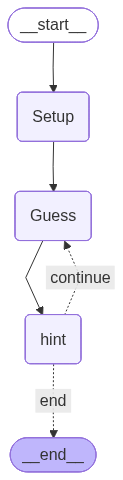

In [8]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "higher_bound": 20})

Welcome to the game Student the game has begun try to guess an number between 1 and 20
Attempt 1:Guessing 2 in Current Range(1-20)
Hint: The Guess 2 Too lower, Try Higher
Continuing:1/7 attempts used.
Attempt 2:Guessing 8 in Current Range(3-20)
Hint: The Guess 8 Too lower, Try Higher
Continuing:2/7 attempts used.
Attempt 3:Guessing 19 in Current Range(9-20)
Hint: The Guess 19 Too higher, Try lower
Continuing:3/7 attempts used.
Attempt 4:Guessing 12 in Current Range(9-18)
You have Found the correct number in 4 attempts
Game Over, You found the number 12.
